## Importy 

In [3]:
import pandas as pd 
from features import extract_features
from modelsUnet import UNet4Levels, UNet, predict_masks, preprocess_image, test_model
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataset import train_loader, val_loader, test_loader
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

## UNet Model 

In [4]:
model = UNet4Levels(in_channels=3, out_channels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet4_cell_nucleus_4_50_1310.pth"))
model.to(device)

UNet4Levels(
  (encoder1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, af

# TRAIN I TEST SET

In [5]:
df1 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_train_new_unet.csv')
df2 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_val_new_unet.csv')
df_test = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_test_new_unet.csv')
df_train = pd.concat([df1, df2], ignore_index=True)


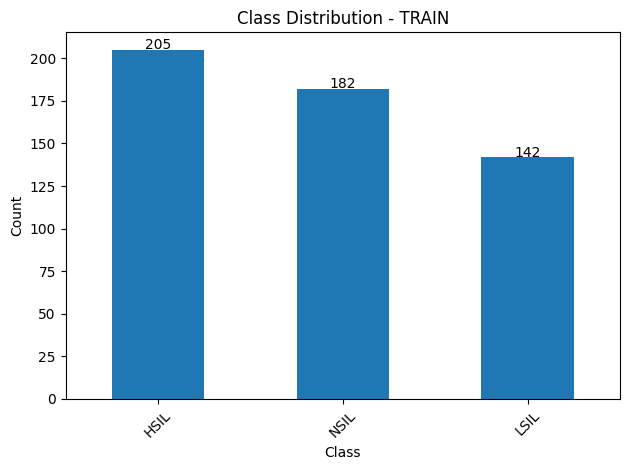

In [6]:
df_train = df_train[df_train['N'] != 0]
df_train['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TRAIN')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_train['class'].value_counts()):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

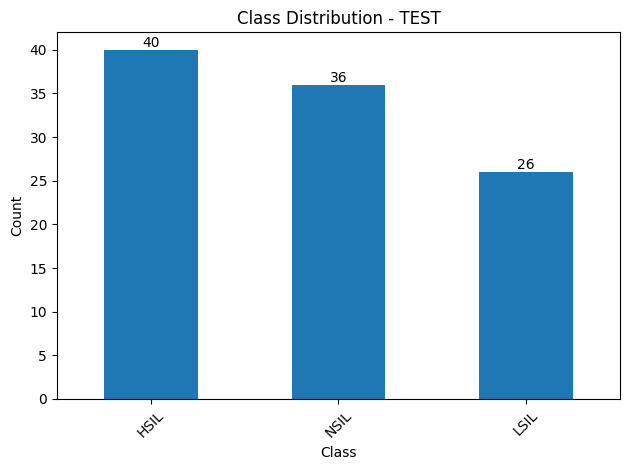

In [7]:
df_test = df_test[df_test['N'] != 0]
df_test['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TEST')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_test['class'].value_counts()):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df_train.head()

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,NSol,CSol,NCs,EqN,EqC,NCEq,OrN,OrC,NCOr,class
0,6351,17492,0.363080,410.391916,1065.997036,0.384984,61.330521,0.600752,145.526630,0.521758,...,0.947769,0.795706,1.191105,89.924103,149.236410,0.602561,-0.239361,0.040196,-5.954837,HSIL
1,5550,12251,0.453024,348.232536,492.114785,0.707625,59.385822,0.715382,121.918005,0.589975,...,0.954428,0.997720,0.956610,84.062355,124.893786,0.673071,14.904083,35.629260,0.418310,HSIL
2,978,3125,0.312960,162.568541,287.338093,0.565774,17.233763,0.521670,68.658576,0.553968,...,0.956947,0.996492,0.960316,35.287792,63.078313,0.559428,-0.439244,-0.458938,0.957087,HSIL
3,864,2465,0.350507,152.752307,236.007140,0.647236,16.963255,0.517228,65.192024,0.663122,...,0.945295,0.998380,0.946829,33.167438,56.022634,0.592036,-2.856079,-7.153759,0.399242,HSIL
4,13099,44180,0.296492,697.511754,960.950353,0.725856,108.330750,0.582786,197.294197,0.570527,...,0.869672,0.992597,0.876158,129.143969,237.174457,0.544510,-2.943298,4.890625,-0.601824,HSIL


In [9]:
df_train.shape

(529, 26)

In [10]:
X_train, y_train = df_train.drop(columns=["class"]), df_train["class"]
X_test,  y_test  = df_test.drop(columns=["class"]),  df_test["class"]

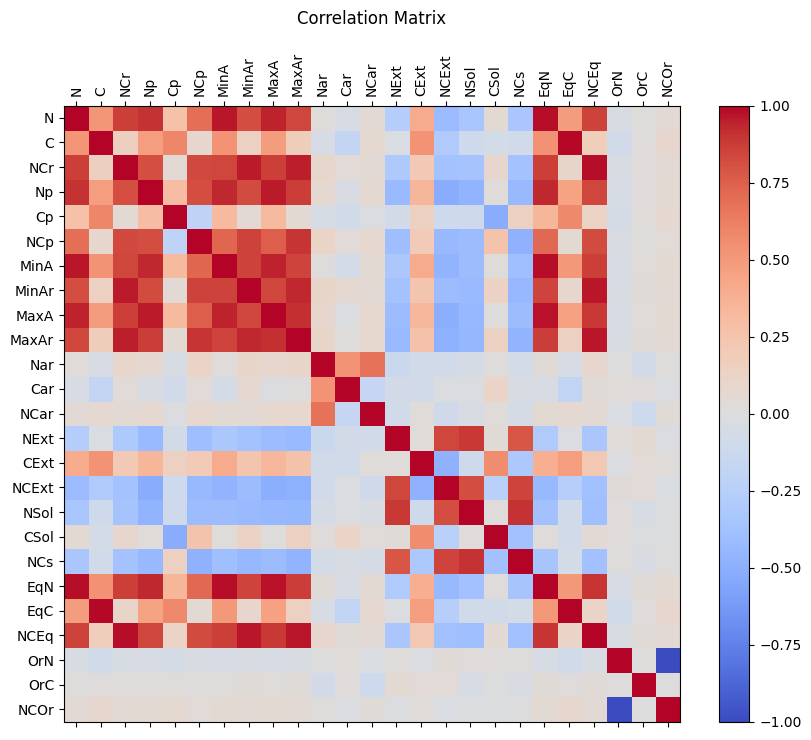

In [11]:
corr = df_train[['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
       'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
       'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="coolwarm")  # możesz zmienić cmap
fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix", pad=20)
plt.show()

## Uczenie z KFold i GridSearch (scalar i smote w pipeline - aby nie było wycieku danych)

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_svm = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", SVC(probability=True, random_state=42))
])

pipe_mlp = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", MLPClassifier(solver="adam", random_state=42, max_iter=1000))
])

pipe_rf = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

pipe_xgb = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_lgbm = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", LGBMClassifier(random_state=42))
])

pipelines = {
    "SVM": pipe_svm,
    "NeuralNet": pipe_mlp,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM": pipe_lgbm
}

param_grids = {
    "SVM": {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__gamma": ["scale", 1, 0.1, 0.01, 0.001],
        "clf__kernel": ["rbf", "poly", "sigmoid"]
    },
    "NeuralNet": {
        "clf__hidden_layer_sizes": [(32, 16), (64, 32), (128, 64), (128, 64, 32)],
        "clf__activation": ["relu", "tanh", "logistic"],
        "clf__batch_size": [32, 64, 16],
        "clf__alpha": [1e-4, 1e-3, 1e-2],
        "clf__learning_rate_init": [1e-3, 1e-2], 
        "clf__n_iter_no_change": [10, 20],
        "clf__max_iter": [300, 600, 1000],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 500],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0]
        # Alternatywa dla SMOTE: clf__scale_pos_weight (gdy duża nierównowaga)
    },
    "LightGBM": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [-1, 10, 20],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__num_leaves": [31, 50, 100],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__min_child_samples": [10, 20, 50],
    }
}

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train) 

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

In [14]:
results = []
for name, pipe in pipelines.items():
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        refit=True  
    )
    grid.fit(X_train, y_train_enc)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_test_pred_enc = best_model.predict(X_test)
    y_test_pred = le.inverse_transform(y_test_pred_enc)

    results.append({
        "Model": name,
        "Split": "Test",
        "Best_Params": best_params,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    })

    joblib.dump({"model": best_model, "label_encoder": le}, f"models_paths/best_model_{name}_new_unet.pkl")


results = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n=== Results ===")
print(results)



=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:13:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== GridSearch dla LightGBM ===
Fitting 5 folds for each of 972 candidates, totalling 4860 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000632 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5149
[LightGBM] [Info] Number of data points in the train set: 615, number of used features: 25
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

In [15]:
results.to_csv("classification_results_new_unet.csv", index=False)

In [16]:
results

,Model,Split,Best_Params,Accuracy,Precision,Recall,F1
2,RandomForest,Test,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",0.911765,0.903371,0.906125,0.904601
3,XGBoost,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.901961,0.892700,0.894231,0.893357
4,LightGBM,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.892157,0.882658,0.881410,0.881872
0,SVM,Test,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",0.872549,0.863379,0.861966,0.862566
1,NeuralNet,Test,"{'clf__activation': 'tanh', 'clf__alpha': 0.00...",0.862745,0.848989,0.845584,0.846799


In [18]:

def predict(pipe, label_encoder, input_features):
    feature_names = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr', 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs', 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']
    try:
        X_new = pd.DataFrame([[input_features[feat] for feat in feature_names]], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    y_pred_encoded = pipe.predict(X_new)
    predicted_class = label_encoder.inverse_transform(y_pred_encoded)[0]

    return predicted_class


In [19]:
classifier = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_new_unet.pkl")
label_encoder = classifier["label_encoder"]
pipe = classifier["model"]


In [20]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test\LSIL\1b_1_aug0.png')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(6466), 'C': np.uint64(37586), 'NCr': np.float64(0.17203213962645666), 'Np': 348.19090592861176, 'Cp': 875.5361388921738, 'NCp': 0.39768878800272234, 'MinA': 77.01443481445312, 'MinAr': 0.4291374005106574, 'MaxA': np.float64(107.93516572461452), 'MaxAr': np.float64(0.376389287941419), 'Nar': 0.898989898989899, 'Car': 0.9375, 'NCar': 0.958922558922559, 'NExt': np.float64(0.7338554080127114), 'CExt': np.float64(0.6117513020833333), 'NCExt': np.float64(1.1995976232719894), 'NSol': np.float64(1.007165109034268), 'CSol': np.float64(0.9204020912663916), 'NCs': np.float64(1.0942664283264483), 'EqN': np.float64(90.73459591719998), 'EqC': np.float64(218.76010040319468), 'NCEq': np.float64(0.4147675730170534), 'OrN': np.float64(-6.001196411414895), 'OrC': np.float64(-18.087124485542155), 'NCOr': np.float64(0.3317938357869942)}
Predicted class: LSIL


In [21]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test\NSIL\22c_1.bmp')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(397), 'C': np.uint64(39333), 'NCr': np.float64(0.01009330587547352), 'Np': 71.94112479686737, 'Cp': 877.9209147691727, 'NCp': 0.08194488089600017, 'MinA': 19.0, 'MinAr': 0.08647312881745019, 'MaxA': np.float64(24.73863375370596), 'MaxAr': np.float64(0.09905919681730352), 'Nar': 1.25, 'Car': 1.031111111111111, 'NCar': 1.2122844827586208, 'NExt': np.float64(0.794), 'CExt': np.float64(0.7535057471264368), 'NCExt': np.float64(1.0537411333994355), 'NSol': np.float64(1.0629183400267737), 'CSol': np.float64(0.9643159223800826), 'NCs': np.float64(1.102251155827983), 'EqN': np.float64(22.48279562821002), 'EqC': np.float64(223.78635126626503), 'NCEq': np.float64(0.1004654461766508), 'OrN': np.float64(0.2672711188917057), 'OrC': np.float64(-1.3911843657002143), 'NCOr': np.float64(-0.19211768438555024)}
Predicted class: NSIL


In [22]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\val\HSIL\2b_1.jpg')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(15298), 'C': np.uint64(56579), 'NCr': np.float64(0.2703830042948797), 'Np': 668.3401824235916, 'Cp': 1539.9797905683517, 'NCp': 0.43399282673503853, 'MinA': 126.12830352783203, 'MinAr': 0.4946207981483609, 'MaxA': np.float64(195.2050204272421), 'MaxAr': np.float64(0.5412972300618094), 'Nar': 0.8181818181818182, 'Car': 1.0, 'NCar': 0.8181818181818182, 'NExt': np.float64(0.53468945510468), 'CExt': np.float64(0.8633270263671875), 'NCExt': np.float64(0.6193359396550011), 'NSol': np.float64(0.7854997304305409), 'CSol': np.float64(0.8874023651933874), 'NCs': np.float64(0.8851674970004848), 'EqN': np.float64(139.5636720474154), 'EqC': np.float64(268.4001121489534), 'NCEq': np.float64(0.5199836577190478), 'OrN': np.float64(0.9111361280152255), 'OrC': np.float64(-2.9331051697443016), 'NCOr': np.float64(-0.31063875152306775)}
Predicted class: HSIL


In [23]:
features = {'N': np.uint64(4439), 'C': np.uint64(262118), 'NCr': np.float64(0.016935120823445927), 'Np': 277.49747383594513, 'Cp': 2309.796025156975, 'NCp': 0.12013938495590158, 'MinA': 73.0, 'MinAr': 0.12784588441331, 'MaxA': np.float64(83.35466393669883), 'MaxAr': np.float64(0.12441202480634707), 'Nar': 1.0405405405405406, 'Car': 1.0367132867132867, 'NCar': 1.0036917187001504, 'NExt': np.float64(0.7790452790452791), 'CExt': np.float64(0.772762650502954), 'NCExt': np.float64(1.008130088246677), 'NSol': np.float64(0.9855683836589698), 'CSol': np.float64(0.9516233848745476), 'NCs': np.float64(1.0356706227736272), 'EqN': np.float64(75.17918820444517), 'EqC': np.float64(577.7014825901795), 'NCEq': np.float64(0.13013500998365476), 'OrN': np.float64(1.446102061602086), 'OrC': np.float64(4.140502931377116), 'NCOr': np.float64(0.349257586715708)}
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Predicted class: LSIL


In [24]:
from sklearn.calibration import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def plot_multiclass_roc(model, label_encoder, classes, X_test, y_test, title="ROC Curve"):
    y_proba = model.predict_proba(X_test)  
    y_true_enc = label_encoder.transform(y_test)               
    plt.figure(figsize=(8, 6))
    n_classes = len(classes)

    y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))

    macro_auc = roc_auc_score(y_true_bin, y_proba, multi_class="ovr", average="macro")
    print(f"Macro AUC (OvR): {macro_auc:.4f}")

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(classes):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        cls_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {cls_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    plt.title(title)
    plt.show()


def print_classification_metrics(y_true, y_pred, classes, title="Classification Metrics"):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    rec_macro = recall_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    print(f"\n=== {title} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (macro): {prec_macro:.4f}")
    print(f"Recall (macro):    {rec_macro:.4f}")
    print(f"F1 (macro):        {f1_macro:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=classes, digits=4))

def evaluate(model_class):
    import os
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, classification_report

    y_true = []
    y_pred = []
    label_encoder = model_class["label_encoder"]
    pipe = model_class["model"]
    folder = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST'
    for subfolder in os.listdir(folder):
        true_class = os.path.basename(subfolder)
        for filename in os.listdir(os.path.join(folder, subfolder)):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                image_path = os.path.join(folder, subfolder, filename)
                pil_image, input_tensor = preprocess_image(image_path)
                predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
                cell_mask = predicted_masks[0]
                nucleus_mask = predicted_masks[1]
                features = extract_features(nucleus_mask, cell_mask)
                predicted_class = predict(pipe, label_encoder, input_features=features)
                y_true.append(true_class)
                y_pred.append(predicted_class)


    acc = accuracy_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=label_encoder.classes_, average="macro", zero_division=0
        )
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=label_encoder.classes_, average="weighted", zero_division=0
        )

    print("\n=== METRYKI (global) ===")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (macro):   {prec_macro:.4f}")
    print(f"Recall    (macro):   {rec_macro:.4f}")
    print(f"F1        (macro):   {f1_macro:.4f}")
    print(f"Precision (weighted):{prec_weighted:.4f}")
    print(f"Recall    (weighted):{rec_weighted:.4f}")
    print(f"F1        (weighted):{f1_weighted:.4f}")

    print("\n=== RAPORT (per klasa) ===")
    print(classification_report(y_true, y_pred, labels=label_encoder.classes_, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_, normalize='true')
    cm_df = pd.DataFrame(
            cm,
            index=[f"true_{l}" for l in label_encoder.classes_],
            columns=[f"pred_{l}" for l in label_encoder.classes_],
        )
    print("\n=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===")
    print(cm_df)



    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title("Confusion Matrix (HSIL/LSIL/NSIL, normalized)")
    tick_marks = np.arange(len(label_encoder.classes_))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(label_encoder.classes_)
    ax.set_yticklabels(label_encoder.classes_)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color="black")

    ax.set_ylabel("True class")
    ax.set_xlabel("Predicted class")
    fig.tight_layout()
    plt.close()

## NN

In [25]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_NeuralNet_new_unet.pkl")

In [26]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

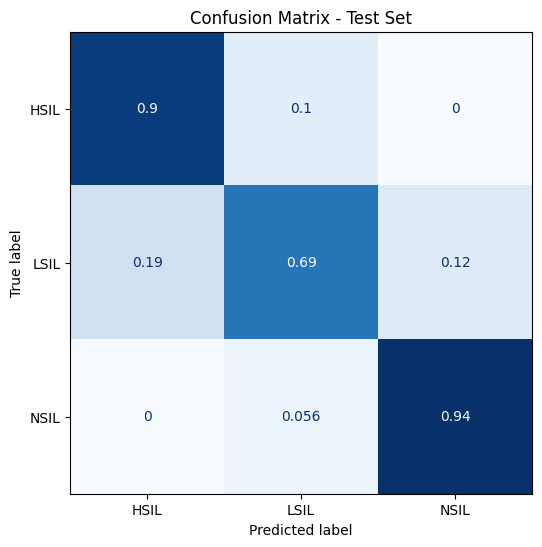

In [27]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

In [28]:
print_classification_metrics(y_test, y_test_pred, classes)


=== Classification Metrics ===
Accuracy:  0.8627
Precision (macro): 0.8490
Recall (macro):    0.8456
F1 (macro):        0.8468

Classification report:
              precision    recall  f1-score   support

        HSIL     0.8780    0.9000    0.8889        40
        LSIL     0.7500    0.6923    0.7200        26
        NSIL     0.9189    0.9444    0.9315        36

    accuracy                         0.8627       102
   macro avg     0.8490    0.8456    0.8468       102
weighted avg     0.8598    0.8627    0.8609       102



In [29]:
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.8276
Precision (macro):   0.8310
Recall    (macro):   0.8296
F1        (macro):   0.8292
Precision (weighted):0.8306
Recall    (weighted):0.8276
F1        (weighted):0.8279

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8889    0.8000    0.8421        20
        LSIL     0.7619    0.8000    0.7805        20
        NSIL     0.8421    0.8889    0.8649        18

    accuracy                         0.8276        58
   macro avg     0.8310    0.8296    0.8292        58
weighted avg     0.8306    0.8276    0.8279        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL   0.800000   0.200000   0.000000
true_LSIL   0.050000   0.800000   0.150000
true_NSIL   0.055556   0.055556   0.888889


Macro AUC (OvR): 0.9406


<Figure size 800x600 with 0 Axes>

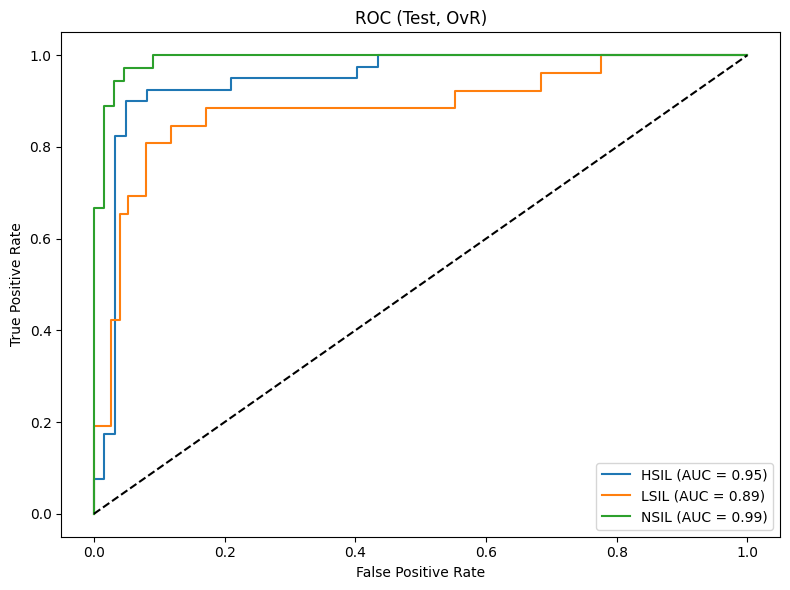

In [30]:
plot_multiclass_roc(model_class['model'], model_class["label_encoder"], classes, X_test, y_test, title="ROC (Test, OvR)")


## XGBOOST

In [31]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_XGBoost_new_unet.pkl")


In [32]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

In [33]:
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.8103
Precision (macro):   0.8234
Recall    (macro):   0.8130
F1        (macro):   0.8160
Precision (weighted):0.8193
Recall    (weighted):0.8103
F1        (weighted):0.8126

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8333    0.7500    0.7895        20
        LSIL     0.6957    0.8000    0.7442        20
        NSIL     0.9412    0.8889    0.9143        18

    accuracy                         0.8103        58
   macro avg     0.8234    0.8130    0.8160        58
weighted avg     0.8193    0.8103    0.8126        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL       0.75   0.250000   0.000000
true_LSIL       0.15   0.800000   0.050000
true_NSIL       0.00   0.111111   0.888889


In [ ]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

## LIGHT GBM

In [34]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_LightGBM_new_unet.pkl")

In [35]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

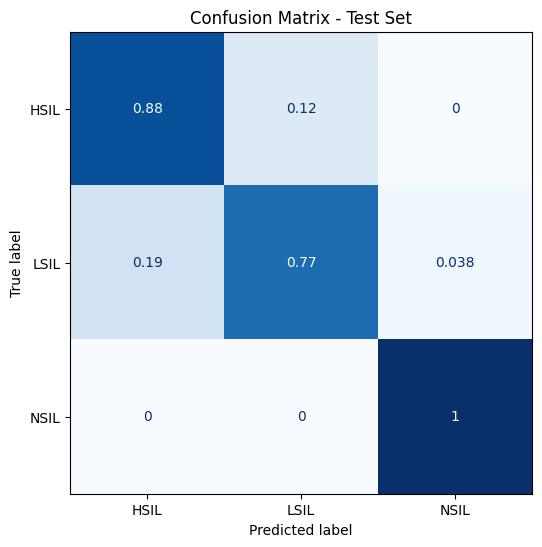

In [36]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

In [37]:
print_classification_metrics(y_test, y_test_pred, classes)


=== Classification Metrics ===
Accuracy:  0.8922
Precision (macro): 0.8827
Recall (macro):    0.8814
F1 (macro):        0.8819

Classification report:
              precision    recall  f1-score   support

        HSIL     0.8750    0.8750    0.8750        40
        LSIL     0.8000    0.7692    0.7843        26
        NSIL     0.9730    1.0000    0.9863        36

    accuracy                         0.8922       102
   macro avg     0.8827    0.8814    0.8819       102
weighted avg     0.8905    0.8922    0.8912       102



In [38]:
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.8448
Precision (macro):   0.8481
Recall    (macro):   0.8500
F1        (macro):   0.8462
Precision (weighted):0.8463
Recall    (weighted):0.8448
F1        (weighted):0.8427

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8824    0.7500    0.8108        20
        LSIL     0.7619    0.8000    0.7805        20
        NSIL     0.9000    1.0000    0.9474        18

    accuracy                         0.8448        58
   macro avg     0.8481    0.8500    0.8462        58
weighted avg     0.8463    0.8448    0.8427        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL       0.75       0.25        0.0
true_LSIL       0.10       0.80        0.1
true_NSIL       0.00       0.00        1.0


In [39]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_SVM_new_unet.pkl")
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.7931
Precision (macro):   0.8097
Recall    (macro):   0.7926
F1        (macro):   0.7976
Precision (weighted):0.8054
Recall    (weighted):0.7931
F1        (weighted):0.7958

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8000    0.8000    0.8000        20
        LSIL     0.6957    0.8000    0.7442        20
        NSIL     0.9333    0.7778    0.8485        18

    accuracy                         0.7931        58
   macro avg     0.8097    0.7926    0.7976        58
weighted avg     0.8054    0.7931    0.7958        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL   0.800000   0.200000   0.000000
true_LSIL   0.150000   0.800000   0.050000
true_NSIL   0.055556   0.166667   0.777778


In [40]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_new_unet.pkl")
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.8103
Precision (macro):   0.8333
Recall    (macro):   0.8111
F1        (macro):   0.8162
Precision (weighted):0.8297
Recall    (weighted):0.8103
F1        (weighted):0.8140

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8824    0.7500    0.8108        20
        LSIL     0.6800    0.8500    0.7556        20
        NSIL     0.9375    0.8333    0.8824        18

    accuracy                         0.8103        58
   macro avg     0.8333    0.8111    0.8162        58
weighted avg     0.8297    0.8103    0.8140        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL       0.75   0.250000   0.000000
true_LSIL       0.10   0.850000   0.050000
true_NSIL       0.00   0.166667   0.833333


In [41]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

In [42]:
print_classification_metrics(y_test, y_test_pred, classes)


=== Classification Metrics ===
Accuracy:  0.9118
Precision (macro): 0.9034
Recall (macro):    0.9061
F1 (macro):        0.9046

Classification report:
              precision    recall  f1-score   support

        HSIL     0.9231    0.9000    0.9114        40
        LSIL     0.8148    0.8462    0.8302        26
        NSIL     0.9722    0.9722    0.9722        36

    accuracy                         0.9118       102
   macro avg     0.9034    0.9061    0.9046       102
weighted avg     0.9128    0.9118    0.9122       102



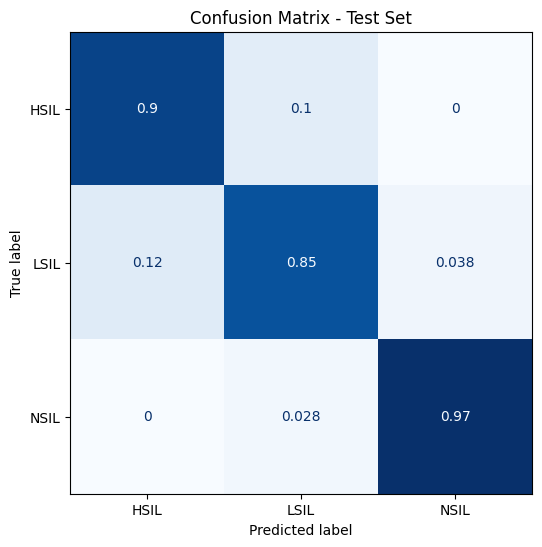

In [43]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

## SHAP dla LIGHTGBM

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


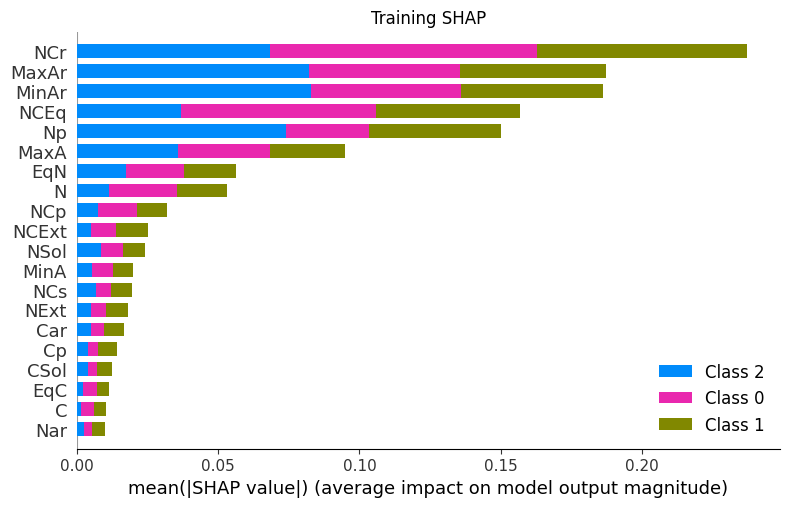

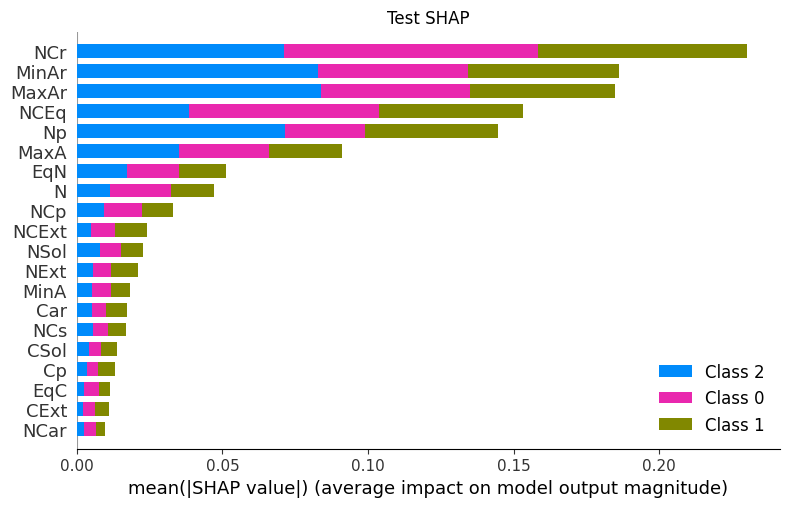

In [44]:
import shap

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_new_unet.pkl")
train_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(df_train.drop('class', axis=1))
test_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(X_test)

plt.subplot(2, 1, 1)
plt.title('Training SHAP')
shap.summary_plot(train_shap_values, df_train.drop('class', axis=1), plot_type="bar")

plt.subplot(2, 1, 2)
plt.title('Test SHAP')
shap.summary_plot(test_shap_values, X_test, plot_type="bar")

In [143]:
class_names = model_class["label_encoder"].classes_
print(class_names) 

['HSIL' 'LSIL' 'NSIL']


## LIME

In [ ]:
import pandas as pd
import joblib
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_new_unet.pkl")
label_encoder = model_class["label_encoder"]

TARGET = "class"
feature_names = list(df_train.drop(columns=[TARGET]).columns)

# 
X_train = df_train.drop(columns=[TARGET])
y_train = label_encoder.transform(df_train[TARGET])

df_test = df_test[df_test[TARGET].notna()].copy()
X_test = df_test.drop(columns=[TARGET])
y_test = label_encoder.transform(df_test[TARGET])

X_train_np = X_train.values
X_test_np  = X_test.values

explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=list(label_encoder.classes_),
    mode="classification",
    random_state=42
)


predict_fn = lambda data: model_class["model"].predict_proba(
    pd.DataFrame(data, columns=feature_names)
)




In [146]:
## LIME DLA NN 
import pandas as pd
import joblib
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_NeuralNet4.pkl")
label_encoder = model_class["label_encoder"]

TARGET = "class"
feature_names = list(df_train.drop(columns=[TARGET]).columns)

# 
X_train = df_train.drop(columns=[TARGET])
y_train = label_encoder.transform(df_train[TARGET])

df_test = df_test[df_test[TARGET].notna()].copy()
X_test = df_test.drop(columns=[TARGET])
y_test = label_encoder.transform(df_test[TARGET])

X_train_np = X_train.values
X_test_np  = X_test.values

explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=list(label_encoder.classes_),
    mode="classification",
    random_state=42
)


predict_fn = lambda data: model_class["model"].predict_proba(
    pd.DataFrame(data, columns=feature_names)
)

In [147]:
features= {'N': np.uint64(17306), 'C': np.uint64(44893), 'NCr': np.float64(0.38549439779030137), 'Np': 659.2518683671951, 'Cp': 814.4823170900345, 'NCp': 0.8094121315273688, 'MinA': 126.82635498046875, 'MinAr': 0.5467992506625384, 'MaxA': np.float64(194.94101672044292), 'MaxAr': np.float64(0.683986725869078), 'Nar': 0.7864583333333334, 'Car': 0.995850622406639, 'NCar': 0.7897352430555555, 'NExt': np.float64(0.5969232891832229), 'CExt': np.float64(0.77615836791148), 'NCExt': np.float64(0.7690740883068098), 'NSol': np.float64(0.9169227508742185), 'CSol': np.float64(1.0004568499637863), 'NCs': np.float64(0.916504046033978), 'EqN': np.float64(148.4408419579555), 'EqC': np.float64(239.0806200464514), 'NCEq': np.float64(0.6208819515739699), 'OrN': np.float64(0.7013970988453097), 'OrC': np.float64(14.2163906145489), 'NCOr': np.float64(0.04933721349267848)}

row = features.values()
row = np.array(list(row))
len(row)

25

In [148]:
model_class["model"].predict_proba([row])

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.80000753, 0.19238596, 0.00760651]])

In [149]:
exp = explainer.explain_instance(
    data_row=row,
    predict_fn=predict_fn, 
    top_labels=len(label_encoder.classes_))

exp.save_to_file("lime_explanation3.html")